In [1]:
import pandas as pd
import numpy as np
import glob
import os
import seaborn as sns
import scipy.stats as stats

def process_csv(csv_file):
    df = pd.read_csv(csv_file, usecols=['Name', 'Points'])
    
    # 20260227_Cos7CoReimaged_p01p08_1_1.csv
    # 20260227_Cos7CoReimaged_p01p08_1_1_0002.csv
    df['filename'] = os.path.basename(csv_file)

    filename_parts = df['filename'].str.split('.')[0][0].split('_')  # Remove extension and split by '_'

    plasmid_mapping = {'p01':'Celsr1-WT',
                       'p02':'Celsr-WT-mCherry',
                       'p04':'Vang2-GFP',
                       'p08':'Fzd6-mCherry',
                       'p09':'Celsr1-Crsh-GFP',
                       'p11':'Celsr1-Crsh-mCherry',
                       }
    
    # Extract metadata
    
    df['date'] = filename_parts[0]
    df['Celsr1_Plasmid'] = filename_parts[2][0:3]
    df['Celsr1_Variant'] = df['Celsr1_Plasmid'].map(plasmid_mapping)
    df['Fz6_Plasmid'] = filename_parts[2][3:6]
    df['Fz6_Variant'] = df['Fz6_Plasmid'].map(plasmid_mapping)
    df['Replicate'] = int(filename_parts[3])
    df['coverslip'] = int(filename_parts[4])
    if len(filename_parts) > 5:
        df['image_number'] = filename_parts[5]
    else:
        df['image_number'] = "0000"
        df['filename'] = df['filename'].str.slice(0,-4)+ "_0000.csv"  # Append _0000 to filename if image_number is not present

    return df

In [2]:
csv_dir = "C:/Users/wgiang/Documents/2026-04-07_Sarah-Fz6-coloc/04_CSV/"
csv_files = glob.glob(os.path.join(csv_dir, "*.csv"))

df = pd.DataFrame()  # Initialize an empty DataFrame to store results
for csv_file in csv_files:
    df_temp = process_csv(csv_file)
    df = pd.concat([df, df_temp], ignore_index=True)

In [3]:
df.head()

,Name,Points,filename,date,Celsr1_Plasmid,Celsr1_Variant,Fz6_Plasmid,Fz6_Variant,Replicate,coverslip,image_number
0,Celsr1_positive,4,20260227_Cos7CoReimaged_p01p08_1_1_0000.csv,20260227,p01,Celsr1-WT,p08,Fzd6-mCherry,1,1,0000
1,Frizzled6_positive,2,20260227_Cos7CoReimaged_p01p08_1_1_0000.csv,20260227,p01,Celsr1-WT,p08,Fzd6-mCherry,1,1,0000
2,Celsr1_positive_and_Frizzled6_positive,51,20260227_Cos7CoReimaged_p01p08_1_1_0000.csv,20260227,p01,Celsr1-WT,p08,Fzd6-mCherry,1,1,0000
3,Celsr1_positive,3,20260227_Cos7CoReimaged_p01p08_1_1_0002.csv,20260227,p01,Celsr1-WT,p08,Fzd6-mCherry,1,1,0002
4,Frizzled6_positive,1,20260227_Cos7CoReimaged_p01p08_1_1_0002.csv,20260227,p01,Celsr1-WT,p08,Fzd6-mCherry,1,1,0002


In [4]:
df.to_csv("merged_fz6_coloc.csv", index=False)

In [5]:
# Group by filename, Replicate, Celsr1_Variant, and Name to sum Points
summary = df.groupby(['filename', 'Replicate', 'Celsr1_Variant', 'Name'])['Points'].sum().reset_index()

# Pivot to have Names as columns
pivot = summary.pivot_table(index=['filename', 'Replicate', 'Celsr1_Variant'], columns='Name', values='Points', fill_value=0).reset_index()

# Calculate total Celsr1 puncta and percentage of Celsr1 puncta that are also Frizzled6 positive
pivot['total_Celsr1'] = pivot['Celsr1_positive'] + pivot['Celsr1_positive_and_Frizzled6_positive']
pivot['percentage_colocalized_Celsr1-Frizzled6'] = (pivot['Celsr1_positive_and_Frizzled6_positive'] / pivot['total_Celsr1']) * 100

# Display the result
pivot[['filename', 'Replicate', 'Celsr1_Variant', 'percentage_colocalized_Celsr1-Frizzled6']]

Name,filename,Replicate,Celsr1_Variant,percentage_colocalized_Celsr1-Frizzled6
0,20260227_Cos7CoReimaged_p01p08_1_1_0000.csv,1,Celsr1-WT,92.727273
1,20260227_Cos7CoReimaged_p01p08_1_1_0002.csv,1,Celsr1-WT,85.714286
2,20260227_Cos7CoReimaged_p01p08_1_1_0004.csv,1,Celsr1-WT,100.000000
3,20260227_Cos7CoReimaged_p01p08_1_1_0005.csv,1,Celsr1-WT,100.000000
4,20260227_Cos7CoReimaged_p01p08_1_2_0000.csv,1,Celsr1-WT,100.000000
5,20260227_Cos7CoReimaged_p01p08_1_2_0001.csv,1,Celsr1-WT,100.000000
6,20260227_Cos7CoReimaged_p01p08_1_2_0002.csv,1,Celsr1-WT,96.875000
7,20260227_Cos7CoReimaged_p01p08_1_3_0000.csv,1,Celsr1-WT,100.000000
8,20260227_Cos7CoReimaged_p01p08_1_3_0001.csv,1,Celsr1-WT,100.000000
9,20260227_Cos7CoReimaged_p01p08_2_2_0001.csv,2,Celsr1-WT,100.000000


In [6]:
pivot.to_csv("pivot_fz6_coloc.csv", index=False)

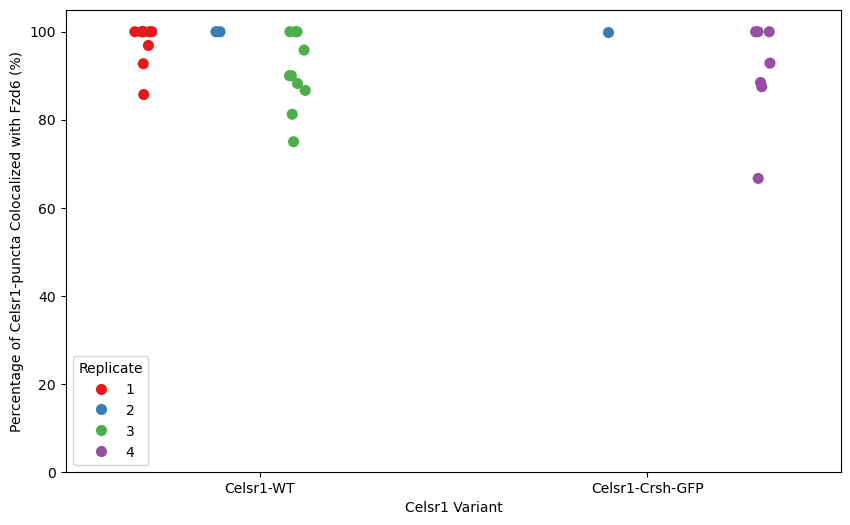

Statistics Summary:
    Celsr1_Variant  Replicate        mean        std  count
0  Celsr1-Crsh-GFP          2  100.000000        NaN      1
1  Celsr1-Crsh-GFP          4   90.783621  11.950775      7
2        Celsr1-WT          1   97.257395   4.988022      9
3        Celsr1-WT          2  100.000000   0.000000      2
4        Celsr1-WT          3   90.698529   8.465198     10
Celsr1-WT replicate means (N=3): [ 97.25739538 100.          90.69852941]
Celsr1-Crsh-GFP replicate means (N=2): [100.          90.78362114]
Mann-Whitney U on replicate averages: U-statistic=2.5000, P-value=1.0000


In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.stripplot(data=pivot, x='Celsr1_Variant', y='percentage_colocalized_Celsr1-Frizzled6', hue='Replicate', palette='Set1', dodge=True, size=8)
#plt.title('Percentage of Colocalized Celsr1-Fzd6 Puncta by Celsr1 Variant and Replicate')
plt.ylabel('Percentage of Celsr1-puncta Colocalized with Fzd6 (%)')
plt.xlabel('Celsr1 Variant')
plt.ylim(0, 105)
plt.legend(title='Replicate')
plt.show()

# Calculate statistics
stats_summary = pivot.groupby(['Celsr1_Variant', 'Replicate'])['percentage_colocalized_Celsr1-Frizzled6'].agg(['mean', 'std', 'count']).reset_index()
print("Statistics Summary:")
print(stats_summary)

# Mann-Whitney test using replicate averages as single N per replicate
wt_means = pivot[pivot['Celsr1_Variant'] == 'Celsr1-WT'].groupby('Replicate')['percentage_colocalized_Celsr1-Frizzled6'].mean()
crsh_means = pivot[pivot['Celsr1_Variant'] == 'Celsr1-Crsh-GFP'].groupby('Replicate')['percentage_colocalized_Celsr1-Frizzled6'].mean()

print("Celsr1-WT replicate means (N=3):", wt_means.values)
print("Celsr1-Crsh-GFP replicate means (N=2):", crsh_means.values)

stat, p = stats.mannwhitneyu(wt_means, crsh_means, alternative='two-sided')
print(f"Mann-Whitney U on replicate averages: U-statistic={stat:.4f}, P-value={p:.4f}")